# Design Violation Analysis – Visualizations (v3)

Charts and insights from Expertiza PR evaluations using the v3 format (13 violation types, LLM + static).

In [57]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
from scipy.stats import pearsonr


def normalize_semester(semester):
    """Normalize to 'Season YYYY' and return (normalized_str, sort_key)."""
    if not semester or not isinstance(semester, str):
        return ("", 0)
    s = str(semester).strip()
    s = re.sub(r"\s*\([^)]*\)\s*", " ", s).strip()
    year, season = None, None
    m = re.search(r"(\d{4})\s+(Fall|Spring)", s, re.IGNORECASE)
    if m:
        year, season = int(m.group(1)), m.group(2).capitalize()
    if year is None or season is None:
        m = re.search(r"(Fall|Spring)\s+(\d{4})", s, re.IGNORECASE)
        if m:
            season, year = m.group(1).capitalize(), int(m.group(2))
    if year is None or season is None:
        return (str(semester), 0)
    return (f"{season} {year}", year * 10 + (1 if season.lower() == "spring" else 2))

# Violation types and categories for styling
VIOLATION_TYPES = [
    "srp", "dry", "lod", "long_chain", "cmo", "lsp",
    "god_object", "feature_envy", "long_method", "shotgun_surgery", "ocp",
    "dip", "information_expert",
]
CLASS_LEVEL = ["srp", "god_object", "cmo", "lsp", "ocp"]
METHOD_LEVEL = ["feature_envy", "long_method", "dry", "information_expert", "dip"]
COUPLING = ["lod", "long_chain", "shotgun_surgery"]

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

# Load insights_v3.csv (run: python3 analyze_evaluations_v3.py --export insights_v3.csv)
csv_path = Path("insights_v3.csv")
if not csv_path.exists():
    print("insights_v3.csv not found. Run: python3 analyze_evaluations_v3.py --export insights_v3.csv")
    df = None
else:
    df = pd.read_csv(csv_path)
    # Normalize semester to "Season YYYY" and add sort_key
    if "semester" in df.columns:
        df["semester"] = df["semester"].fillna("").astype(str)
        normed = df["semester"].apply(normalize_semester)
        df["semester"] = normed.apply(lambda x: x[0])
        df["sort_key"] = normed.apply(lambda x: x[1])
        parts = df["semester"].str.split()
        df["season"] = parts.str[0].fillna("")
        df["year"] = pd.to_numeric(parts.str[1], errors="coerce")
    if "year" in df.columns and df["year"].isna().any():
        df["year"] = pd.to_numeric(df["year"], errors="coerce")
    print(f"Loaded {len(df)} project evaluations")
    print(f"Shape: {df.shape}")
    df.head()

Loaded 732 project evaluations
Shape: (732, 37)


## Chart 1: Total Violations by Semester (Line Chart)

Average LLM and static violations per project across semesters in chronological order.

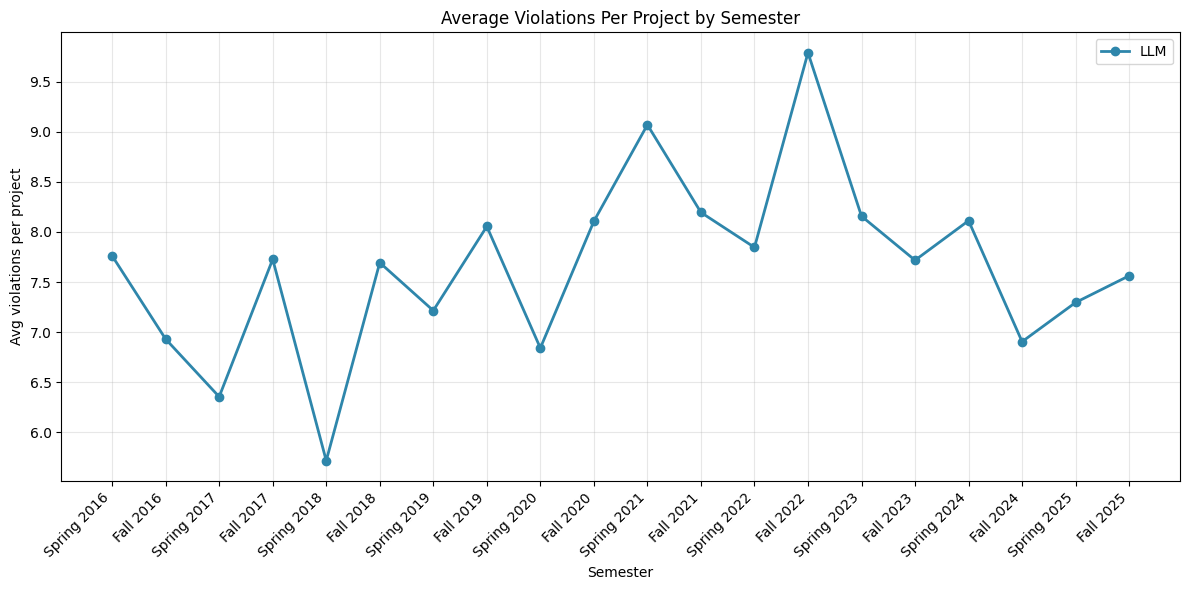

In [58]:
if df is not None and len(df) > 0:
    # Sort semesters chronologically using sort_key (Spring before Fall within same year)
    sem_order = df.groupby("semester").agg({"sort_key": "first"}).reset_index()
    sem_order = sem_order.sort_values("sort_key")
    semesters = sem_order["semester"].tolist()

    by_sem = df.groupby("semester").agg({
        "total_llm_violations": "mean",
        "total_static_violations": "mean",
    }).reindex(semesters).dropna(how="all")

    fig, ax = plt.subplots(figsize=(12, 6))
    x = range(len(by_sem.index))
    ax.plot(x, by_sem["total_llm_violations"], "o-", color="#2e86ab", label="LLM", linewidth=2)
    # ax.plot(x, by_sem["total_static_violations"], "s-", color="#e94f37", label="Static", linewidth=2)
    ax.set_xticks(x)
    ax.set_xticklabels(by_sem.index, rotation=45, ha="right")
    ax.set_xlabel("Semester")
    ax.set_ylabel("Avg violations per project")
    ax.set_title("Average Violations Per Project by Semester")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "chart1_violations_by_semester.png", dpi=150, bbox_inches="tight")
    plt.show()

## Chart 2: Violation Type Distribution (Horizontal Bar)

Total LLM violations by type, sorted by frequency. Color-coded by category: class-level (blue), method-level (green), coupling (orange).

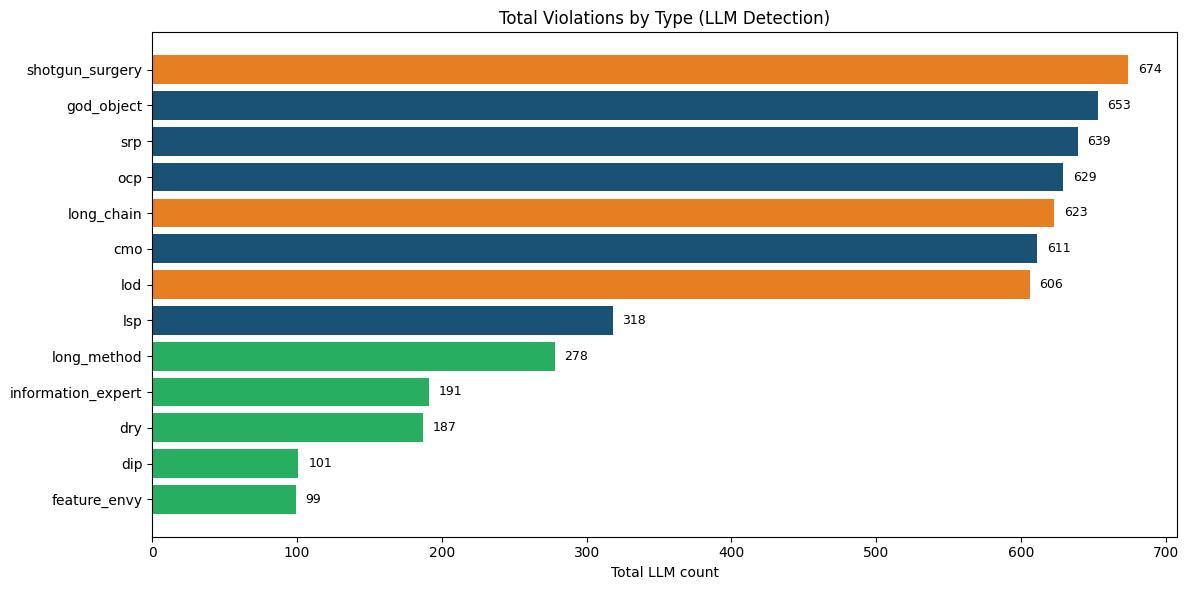

In [59]:
if df is not None and len(df) > 0:
    llm_cols = [f"{vt}_llm" for vt in VIOLATION_TYPES if f"{vt}_llm" in df.columns]
    type_totals = df[llm_cols].sum().sort_values(ascending=True)
    type_totals.index = [x.replace("_llm", "") for x in type_totals.index]

    colors = []
    for vt in type_totals.index:
        if vt in CLASS_LEVEL:
            colors.append("#1a5276")
        elif vt in METHOD_LEVEL:
            colors.append("#27ae60")
        else:
            colors.append("#e67e22")

    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.barh(type_totals.index, type_totals.values, color=colors)
    ax.set_xlabel("Total LLM count")
    ax.set_title("Total Violations by Type (LLM Detection)")
    for i, v in enumerate(type_totals.values):
        if v > 0:
            ax.text(v + max(type_totals.values) * 0.01, i, str(int(v)), va="center", fontsize=9)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "chart2_violation_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()

## Chart 3: Semester Heatmap

Rows: 13 violation types. Columns: semesters. Values: avg violations per project. White = 0, darker = higher.

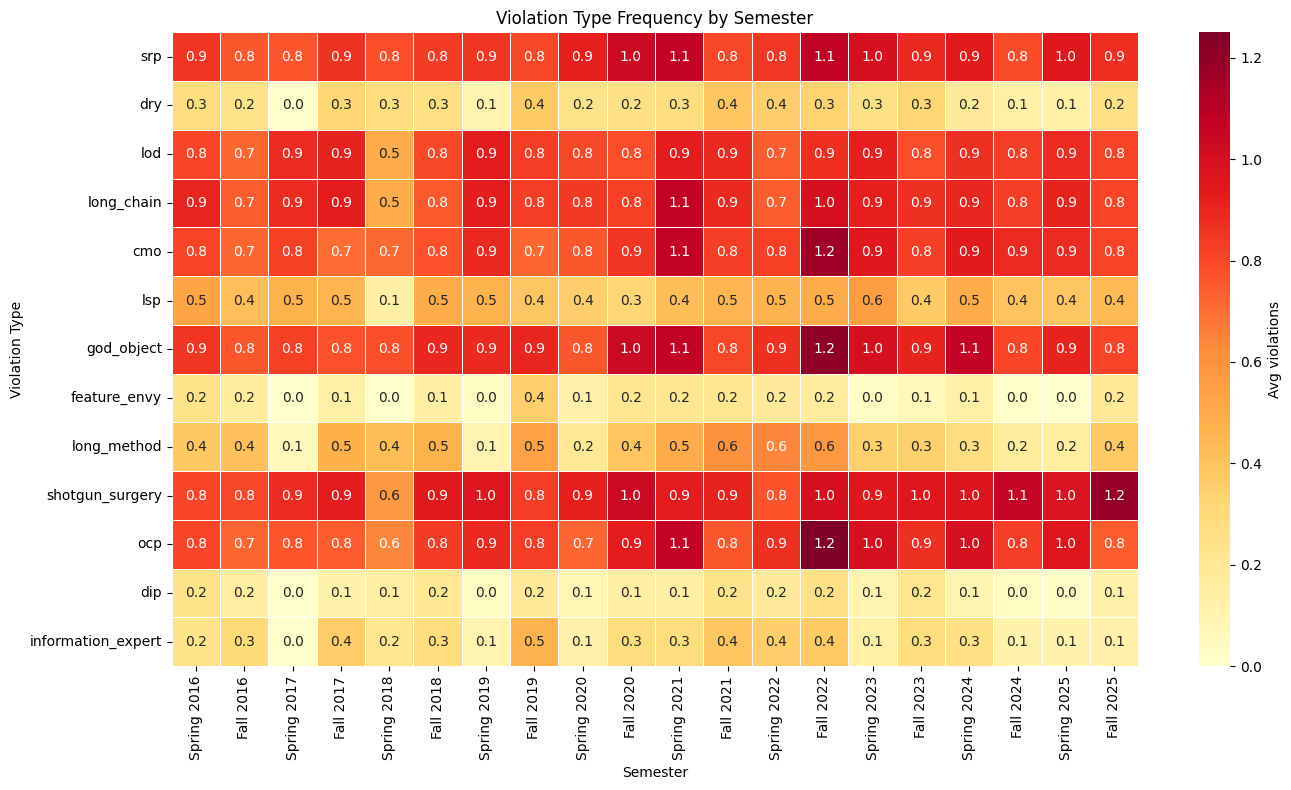

In [60]:
if df is not None and len(df) > 0:
    sem_order = df.groupby("semester").agg({"sort_key": "first"}).reset_index()
    semesters = sem_order.sort_values("sort_key")["semester"].tolist()
    heat_data = []
    for vt in VIOLATION_TYPES:
        col = f"{vt}_llm"
        if col in df.columns:
            row = df.groupby("semester")[col].mean().reindex(semesters).fillna(0)
            heat_data.append(row.values)
        else:
            heat_data.append([0] * len(semesters))
    heat_df = pd.DataFrame(heat_data, index=VIOLATION_TYPES, columns=semesters)

    fig, ax = plt.subplots(figsize=(14, 8))
    sns.heatmap(heat_df, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={"label": "Avg violations"}, ax=ax, linewidths=0.5)
    ax.set_title("Violation Type Frequency by Semester")
    ax.set_xlabel("Semester")
    ax.set_ylabel("Violation Type")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "chart3_semester_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()

## Chart 4: LLM vs Static Scatter (4x4 Grid)

One subplot per violation type. X = static count, Y = LLM count. Diagonal y=x reference line. Title shows Pearson r.

/var/folders/xs/n8x_3wvj1275wzhw5q2smc080000gn/T/ipykernel_37789/3900795502.py:13: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = pearsonr(x, y)


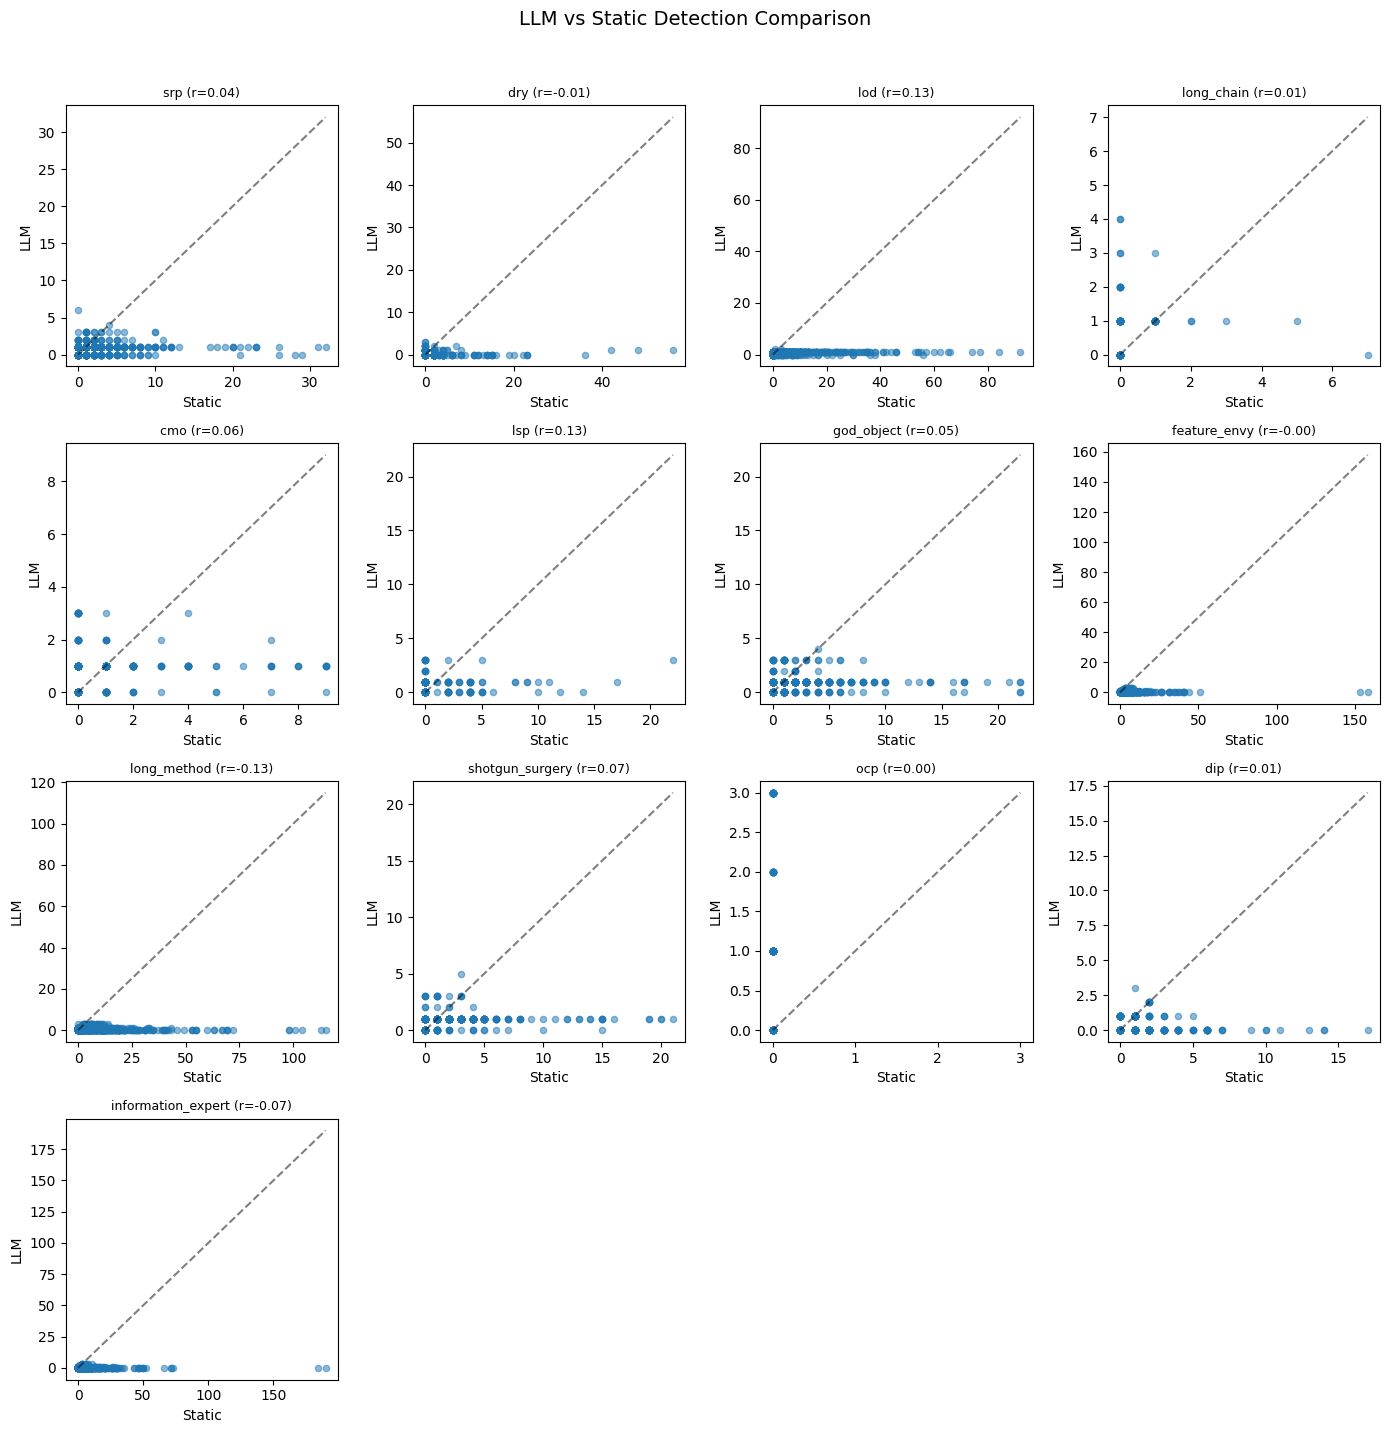

In [61]:
if df is not None and len(df) > 0:
    fig, axes = plt.subplots(4, 4, figsize=(14, 14))
    axes = axes.flatten()
    for idx, vt in enumerate(VIOLATION_TYPES):
        ax = axes[idx]
        s_col, l_col = f"{vt}_static", f"{vt}_llm"
        if s_col in df.columns and l_col in df.columns:
            x, y = df[s_col], df[l_col]
            ax.scatter(x, y, alpha=0.5, s=20)
            lim = max(x.max(), y.max(), 1)
            ax.plot([0, lim], [0, lim], "k--", alpha=0.5)
            try:
                r, _ = pearsonr(x, y)
                r = r if not (r != r) else 0
            except Exception:
                r = 0
            ax.set_title(f"{vt} (r={r:.2f})", fontsize=9)
            ax.set_xlabel("Static")
            ax.set_ylabel("LLM")
        else:
            ax.set_visible(False)
    for idx in range(13, 16):
        axes[idx].set_visible(False)
    fig.suptitle("LLM vs Static Detection Comparison", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "chart4_llm_vs_static.png", dpi=150, bbox_inches="tight")
    plt.show()

## Chart 5: Top 15 Violating Projects (Horizontal Bar)

Projects ranked by total LLM violations. Color by semester.

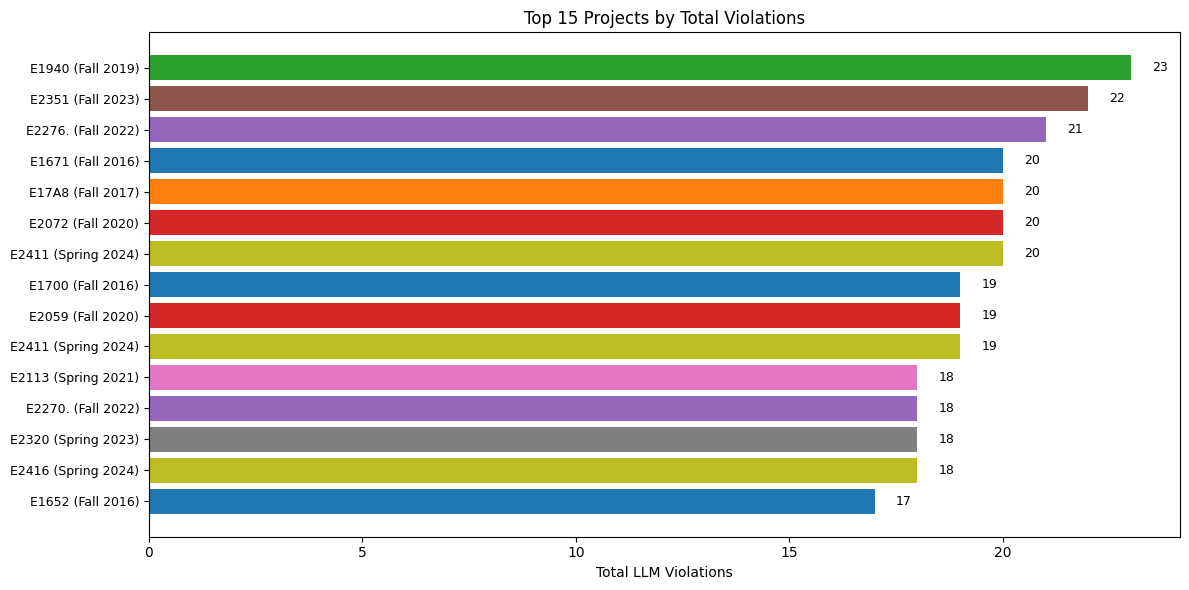

In [62]:
if df is not None and len(df) > 0:
    top = df.nlargest(15, "total_llm_violations").copy()
    top["label"] = top["project_id"].astype(str).str.strip() + " (" + top["semester"].astype(str) + ")"
    sem_colors = pd.Categorical(top["semester"]).codes
    colors = plt.cm.tab10(sem_colors % 10)

    fig, ax = plt.subplots(figsize=(12, 6))
    y_pos = range(len(top))
    bars = ax.barh(y_pos, top["total_llm_violations"], color=colors)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top["label"], fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Total LLM Violations")
    ax.set_title("Top 15 Projects by Total Violations")
    for i, v in enumerate(top["total_llm_violations"]):
        ax.text(v + 0.5, i, str(int(v)), va="center", fontsize=9)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "chart5_top_violators.png", dpi=150, bbox_inches="tight")
    plt.show()

## Chart 6: Violation Co-occurrence Heatmap

13x13 matrix. Cell (i,j) = number of projects where both violation i and j appear (count > 0).

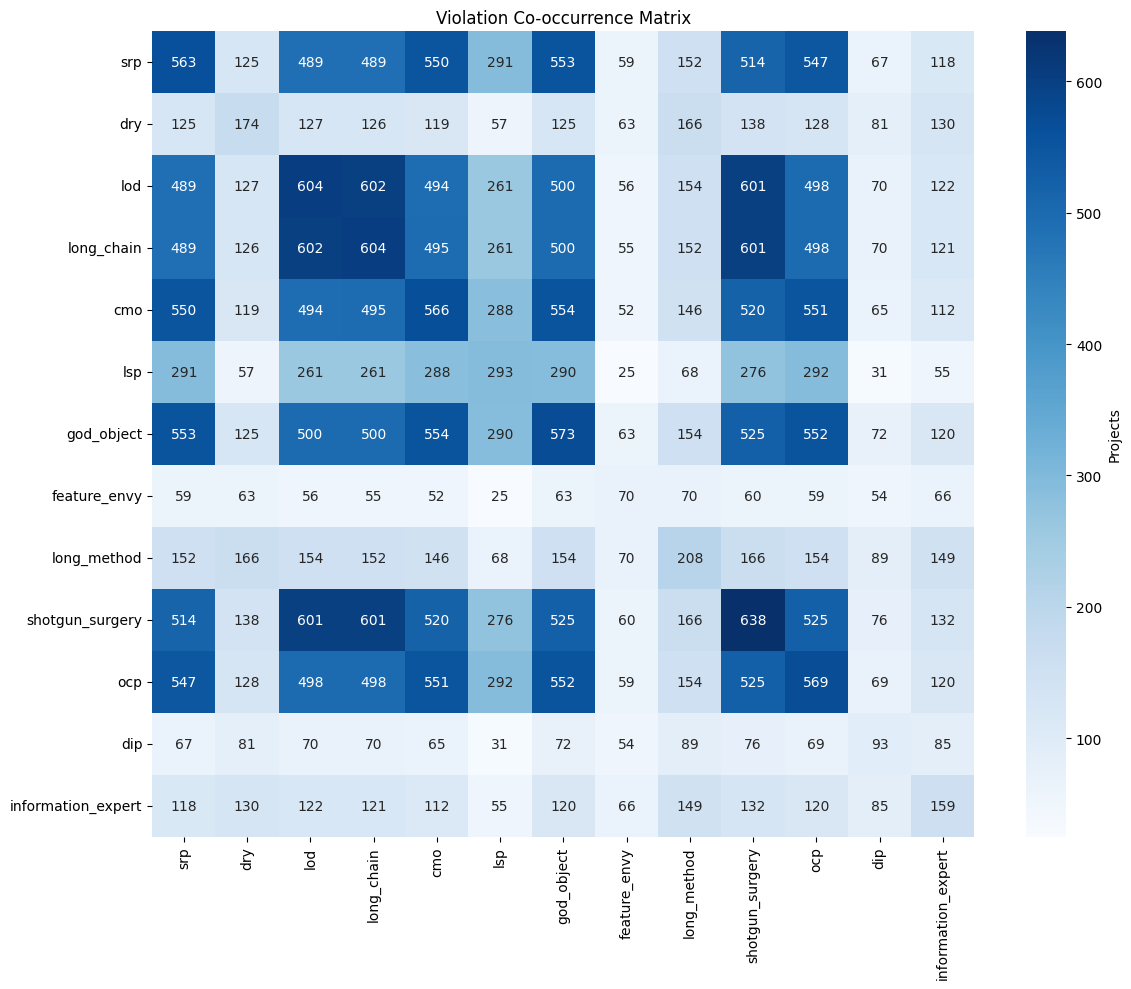

In [63]:
if df is not None and len(df) > 0:
    cooccur = np.zeros((13, 13))
    for i, vt1 in enumerate(VIOLATION_TYPES):
        for j, vt2 in enumerate(VIOLATION_TYPES):
            col1 = f"{vt1}_llm"
            col2 = f"{vt2}_llm"
            if col1 in df.columns and col2 in df.columns:
                cooccur[i, j] = ((df[col1] > 0) & (df[col2] > 0)).sum()

    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(cooccur, xticklabels=VIOLATION_TYPES, yticklabels=VIOLATION_TYPES,
                annot=True, fmt=".0f", cmap="Blues", ax=ax, cbar_kws={"label": "Projects"})
    ax.set_title("Violation Co-occurrence Matrix")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "chart6_cooccurrence.png", dpi=150, bbox_inches="tight")
    plt.show()

## Chart 7: Alignment Score Distribution (Histogram)

Distribution of feedback alignment scores (1-5). Vertical line at mean.

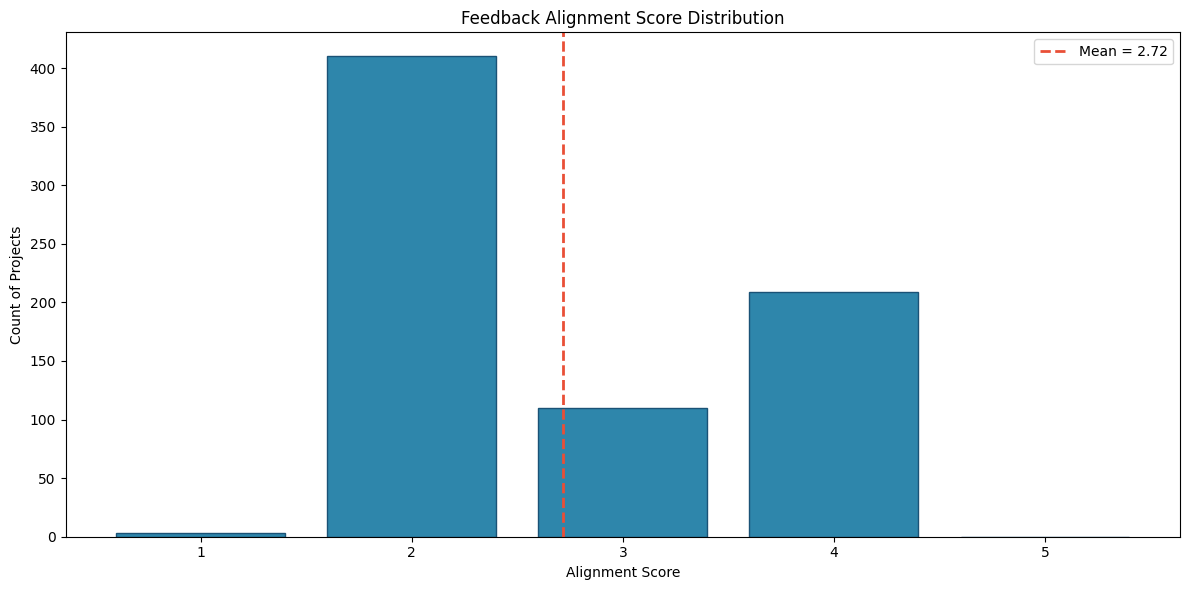

In [64]:
if df is not None and len(df) > 0 and "alignment_score" in df.columns:
    scores = df["alignment_score"].dropna()
    scores = scores[scores.between(1, 5)]
    if len(scores) > 0:
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.hist(scores, bins=range(1, 7), align="left", rwidth=0.8, color="#2e86ab", edgecolor="#1a5276")
        mean_val = scores.mean()
        ax.axvline(mean_val, color="#e94f37", linestyle="--", linewidth=2, label=f"Mean = {mean_val:.2f}")
        ax.set_xlabel("Alignment Score")
        ax.set_ylabel("Count of Projects")
        ax.set_title("Feedback Alignment Score Distribution")
        ax.set_xticks([1, 2, 3, 4, 5])
        ax.legend()
        plt.tight_layout()
        plt.savefig(FIG_DIR / "chart7_alignment_dist.png", dpi=150, bbox_inches="tight")
        plt.show()

## Chart 8: Spring vs Fall Violation Trends by Year

Grouped bar chart: avg total violations by year, with Spring and Fall bars per year.

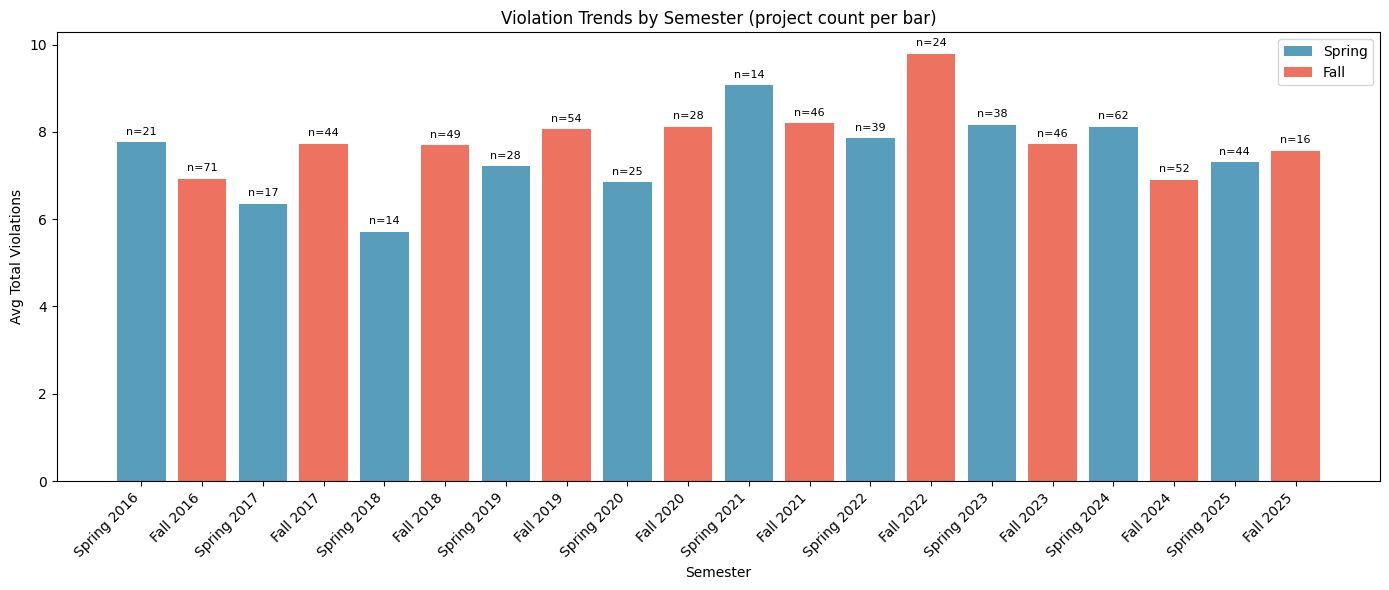

In [65]:
if df is not None and len(df) > 0 and "semester" in df.columns:
    # Order semesters chronologically (each semester separate, not grouped by year)
    sem_order = df.groupby("semester").agg({"sort_key": "first"}).reset_index()
    sem_order = sem_order.sort_values("sort_key")
    semesters = sem_order["semester"].tolist()

    by_sem = df.groupby("semester").agg({
        "total_llm_violations": "mean",
        "project_id": "count"
    }).round(2)
    by_sem.columns = ["avg_violations", "project_count"]
    by_sem = by_sem.reindex(semesters).fillna(0)

    # Color bars by season (Spring vs Fall)
    seasons = [s.split()[0] if " " in s else "" for s in semesters]
    colors = ["#2e86ab" if s == "Spring" else "#e94f37" for s in seasons]

    fig, ax = plt.subplots(figsize=(14, 6))
    x = np.arange(len(semesters))
    bars = ax.bar(x, by_sem["avg_violations"], color=colors, alpha=0.8)

    # Project count annotations on bars (above each bar)
    for i, (v, c) in enumerate(zip(by_sem["avg_violations"], by_sem["project_count"])):
        if c > 0:
            ax.annotate(f"n={int(c)}", (i, v), xytext=(0, 4), textcoords="offset points",
                        ha="center", va="bottom", fontsize=8)

    # # Trendline
    # from matplotlib.patches import Patch
    # from matplotlib.lines import Line2D
    # valid = by_sem["avg_violations"].values > 0
    # if valid.sum() >= 2:
    #     x_fit = x[valid]
    #     y_fit = by_sem["avg_violations"].values[valid]
    #     z = np.polyfit(x_fit, y_fit, 1)
    #     p = np.poly1d(z)
    #     ax.plot(x, p(x), "k--", alpha=0.7, linewidth=2, label="Trend")

    ax.set_xticks(x)
    ax.set_xticklabels(semesters, rotation=45, ha="right")
    ax.set_xlabel("Semester")
    ax.set_ylabel("Avg Total Violations")
    ax.set_title("Violation Trends by Semester (project count per bar)")
    handles = [
        Patch(facecolor="#2e86ab", alpha=0.8, label="Spring"),
        Patch(facecolor="#e94f37", alpha=0.8, label="Fall"),
    ]
    # if valid.sum() >= 2:
    #     handles.append(Line2D([0], [0], color="k", linestyle="--", linewidth=2, label="Trend"))
    ax.legend(handles=handles, loc="upper right")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "chart8_spring_vs_fall.png", dpi=150, bbox_inches="tight")
    plt.show()

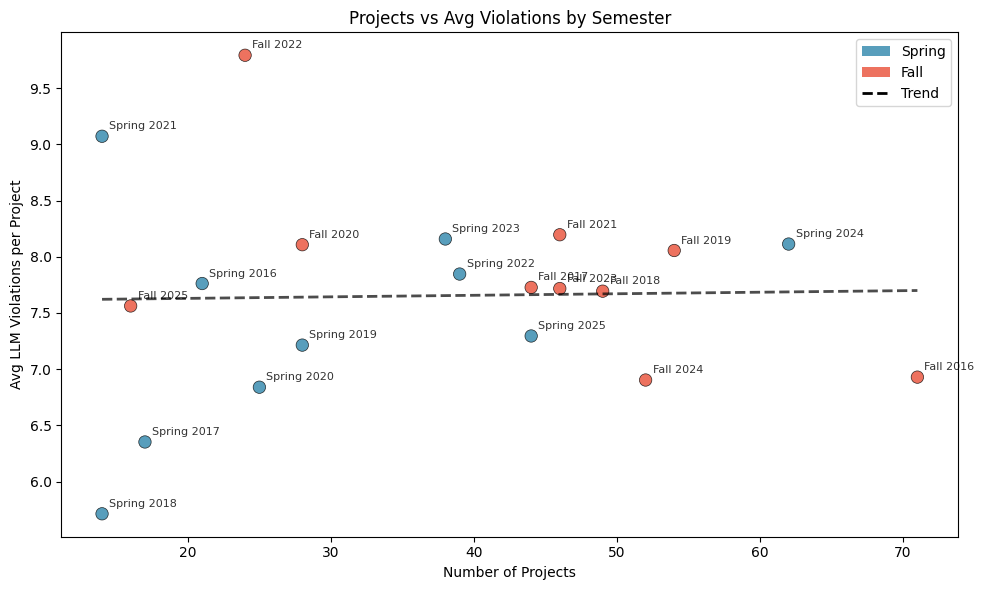

In [72]:
# Chart 8 Part 2: Projects vs Avg Violations per Project (scatter by semester)
if df is not None and len(df) > 0 and "semester" in df.columns:
    sem_order = df.groupby("semester").agg({"sort_key": "first"}).reset_index()
    sem_order = sem_order.sort_values("sort_key")
    semesters = sem_order["semester"].tolist()

    by_sem = df.groupby("semester").agg({
        "total_llm_violations": "mean",
        "project_id": "count"
    })
    by_sem.columns = ["avg_violations", "project_count"]
    by_sem = by_sem.reindex(semesters).fillna(0)

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ["#2e86ab" if s.split()[0] == "Spring" else "#e94f37" for s in semesters]
    ax.scatter(by_sem["project_count"], by_sem["avg_violations"], c=colors, s=80, alpha=0.8, edgecolors="k", linewidths=0.5)

    for i, sem in enumerate(semesters):
        ax.annotate(sem, (by_sem["project_count"].iloc[i], by_sem["avg_violations"].iloc[i]),
                    xytext=(5, 5), textcoords="offset points", fontsize=8, alpha=0.8)

    # Trendline
    valid = (by_sem["project_count"] > 0) & (by_sem["avg_violations"] > 0)
    if valid.sum() >= 2:
        x_fit = by_sem.loc[valid, "project_count"].values
        y_fit = by_sem.loc[valid, "avg_violations"].values
        z = np.polyfit(x_fit, y_fit, 1)
        p = np.poly1d(z)
        x_line = np.linspace(by_sem["project_count"].min(), by_sem["project_count"].max(), 50)
        ax.plot(x_line, p(x_line), "k--", alpha=0.7, linewidth=2, label="Trend")

    ax.set_xlabel("Number of Projects")
    ax.set_ylabel("Avg LLM Violations per Project")
    ax.set_title("Projects vs Avg Violations by Semester")
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    handles = [Patch(facecolor="#2e86ab", alpha=0.8, label="Spring"), Patch(facecolor="#e94f37", alpha=0.8, label="Fall")]
    if valid.sum() >= 2:
        handles.append(Line2D([0], [0], color="k", linestyle="--", linewidth=2, label="Trend"))
    ax.legend(handles=handles, loc="upper right")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "chart8b_projects_vs_violations.png", dpi=150, bbox_inches="tight")
    plt.show()

## Chart 9: Refactoring vs Reimplementation Average Violations

Compare average violation counts (LLM and static) between refactoring projects (legacy Expertiza) and reimplementation projects (backend/frontend reimplementation).

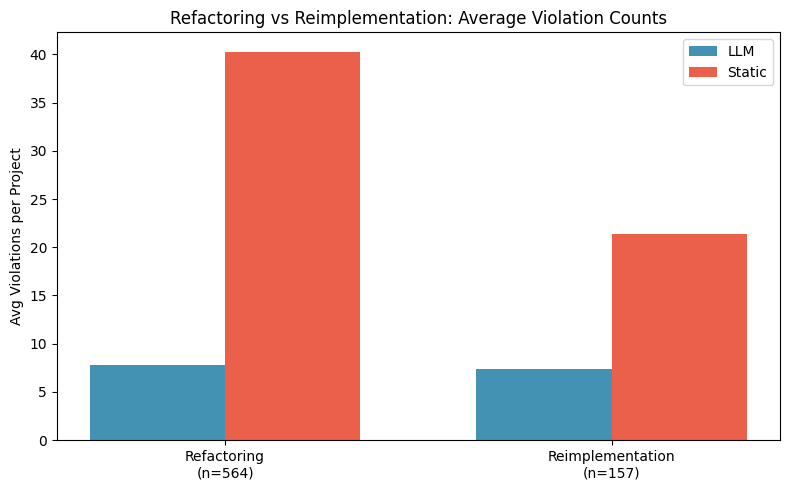

In [67]:
# Chart 9: Refactoring vs Reimplementation average violations
if df is not None and len(df) > 0 and "project_category" in df.columns:
    cat_df = df[df["project_category"].isin(["refactoring", "reimplementation"])]
    if len(cat_df) > 0:
        by_cat = cat_df.groupby("project_category").agg({
            "total_llm_violations": "mean",
            "total_static_violations": "mean",
        }).round(2)
        counts = cat_df.groupby("project_category").size()
        by_cat = by_cat.reindex(["refactoring", "reimplementation"]).fillna(0)

        fig, ax = plt.subplots(figsize=(8, 5))
        x = np.arange(len(by_cat))
        w = 0.35
        ax.bar(x - w/2, by_cat["total_llm_violations"], w, label="LLM", color="#2e86ab", alpha=0.9)
        ax.bar(x + w/2, by_cat["total_static_violations"], w, label="Static", color="#e94f37", alpha=0.9)
        ax.set_xticks(x)
        labels = [f"{cat.capitalize()}\n(n={int(counts.get(cat, 0))})" for cat in by_cat.index]
        ax.set_xticklabels(labels)
        ax.set_ylabel("Avg Violations per Project")
        ax.set_title("Refactoring vs Reimplementation: Average Violation Counts")
        ax.legend()
        ax.set_ylim(bottom=0)
        plt.tight_layout()
        plt.savefig(FIG_DIR / "chart9_refactoring_vs_reimplementation.png", dpi=150, bbox_inches="tight")
        plt.show()
    else:
        print("No refactoring or reimplementation projects in data.")

In [68]:
if df is not None and len(df) > 0:
    llm_cols = [f"{vt}_llm" for vt in VIOLATION_TYPES if f"{vt}_llm" in df.columns]
    stats = df[llm_cols].agg(["mean", "std"]).T
    stats.index = [x.replace("_llm", "") for x in stats.index]
    stats = stats.sort_values("mean", ascending=False)
    stats["mean"] = stats["mean"].round(2)
    stats["std"] = stats["std"].fillna(0).round(2)

    print("Violation Type | Mean | Std")
    print("---|---:|---:")
    for vt in stats.index:
        print(f"{vt} | {stats.loc[vt, 'mean']:.2f} | {stats.loc[vt, 'std']:.2f}")

    print("\n--- LaTeX table ---")
    print(r"\begin{tabular}{lrr}")
    print(r"Violation Type & Mean & Std \\ \hline")
    for vt in stats.index:
        print(f"{vt} & {stats.loc[vt, 'mean']:.2f} & {stats.loc[vt, 'std']:.2f} \\\\")
    print(r"\end{tabular}")

Violation Type | Mean | Std
---|---:|---:
shotgun_surgery | 0.92 | 0.47
god_object | 0.89 | 0.64
srp | 0.87 | 0.63
ocp | 0.86 | 0.59
long_chain | 0.85 | 0.45
cmo | 0.83 | 0.55
lod | 0.83 | 0.38
lsp | 0.43 | 0.58
long_method | 0.38 | 0.71
information_expert | 0.26 | 0.56
dry | 0.26 | 0.48
dip | 0.14 | 0.38
feature_envy | 0.14 | 0.48

--- LaTeX table ---
\begin{tabular}{lrr}
Violation Type & Mean & Std \\ \hline
shotgun_surgery & 0.92 & 0.47 \\
god_object & 0.89 & 0.64 \\
srp & 0.87 & 0.63 \\
ocp & 0.86 & 0.59 \\
long_chain & 0.85 & 0.45 \\
cmo & 0.83 & 0.55 \\
lod & 0.83 & 0.38 \\
lsp & 0.43 & 0.58 \\
long_method & 0.38 & 0.71 \\
information_expert & 0.26 & 0.56 \\
dry & 0.26 & 0.48 \\
dip & 0.14 & 0.38 \\
feature_envy & 0.14 & 0.48 \\
\end{tabular}


In [69]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
X = df[[f"{v}_llm" for v in VIOLATION_TYPES]].fillna(0)
X_scaled = StandardScaler().fit_transform(X)
df["cluster"] = KMeans(n_clusters=4, random_state=42).fit_predict(X_scaled)
